<a href="https://colab.research.google.com/github/mahlaalimardani/13711371/blob/main/Yet_another_copy_of_%D9%8EAI_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import files
uploaded= files.upload()
import pandas as pd
df= pd.read_csv("healthcare-dataset-stroke-data.csv") # Data.csv = file’s name
df.head()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data.csv


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**Section 1**

stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64
stroke
0    95.13
1     4.87
Name: proportion, dtype: float64


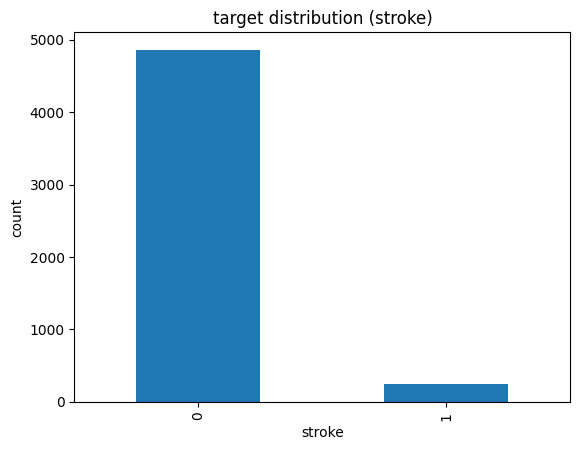

In [4]:
import matplotlib.pyplot as plt
counts_target=df["stroke"].value_counts(dropna=False)
print(counts_target)

target_ratio=df["stroke"].value_counts(dropna=False,normalize=True)
print(target_ratio)

print((target_ratio*100).round(2))

counts_target.plot(kind="bar",title="target distribution (stroke)");plt.xlabel("stroke");plt.ylabel("count")
plt.show()

,mean,median,std,min,max
age,43.227,45.000,22.613,0.08,82.00
avg_glucose_level,106.148,91.885,45.284,55.12,271.74
bmi,28.893,28.100,7.854,10.30,97.60


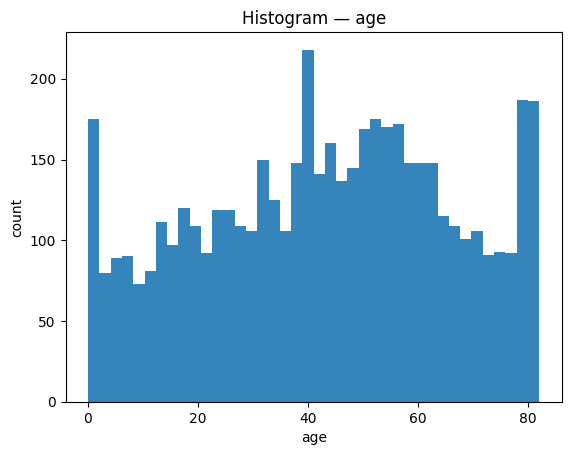

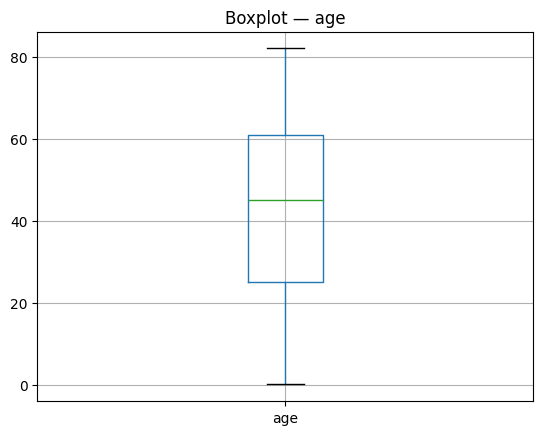

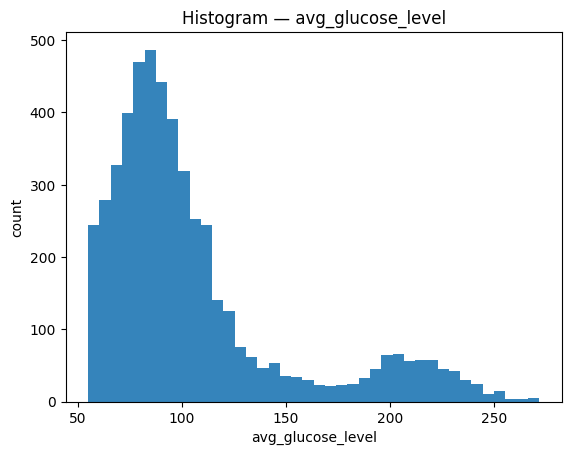

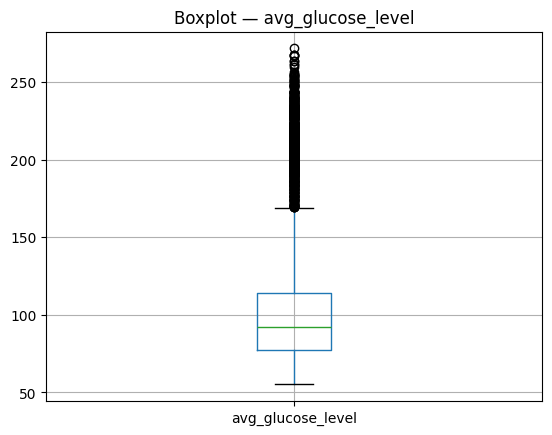

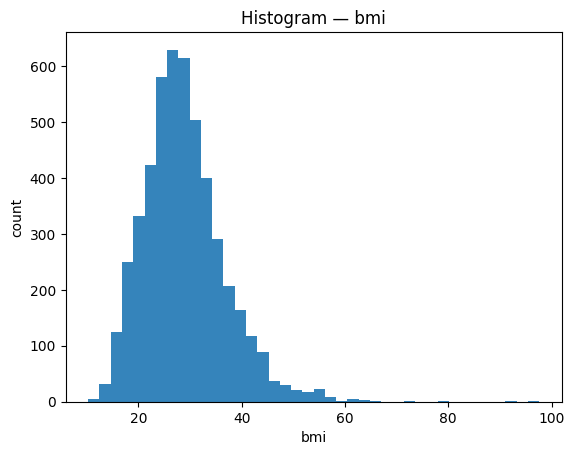

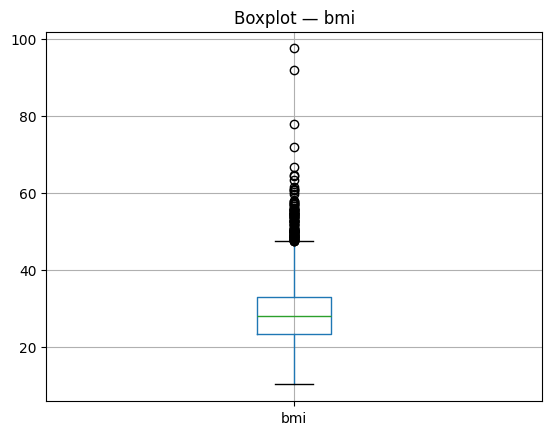

In [5]:
#mean, Median, Std

numeric_cols=["age", "avg_glucose_level","bmi"]
basic_stats=df[numeric_cols].agg(['mean','median','std','min','max']).T.round(3)
display(basic_stats)



#Histogram & boxplot

for a in numeric_cols:
    df[a].plot(kind='hist', bins=40, alpha=0.9,title=f'Histogram — {a}')
    plt.xlabel(a);
    plt.ylabel('count');
    plt.show()

    df[[a]].boxplot(); plt.title(f'Boxplot — {a}');
    plt.show()






In [6]:
#Calculate correlation coefficients

correlation_target=df[numeric_cols+["stroke"]].corr(numeric_only=True).loc[numeric_cols,"stroke"].to_frame("pearson_with_target").round(3)
print(correlation_target)


correlation_matrix=df[numeric_cols].corr(numeric_only=True).round(3)
print(correlation_matrix)


#redundancy
pairwise= df[numeric_cols].corr().round(3)
display(pairwise)


pairwise_abs = pairwise.abs()
np.fill_diagonal(pairwise_abs.values, 0)
max_values = pairwise_abs.values.max()
i, j = np.where(pairwise_abs.values == max_values)
print(f"Strongest numeric pair: {pairwise.index[i[0]]} -> {pairwise.columns[j[0]]} | correlation = {pairwise.values[i[0], j[0]]:.3f}")

threshold= 0.6
pairwise=[]
for r in range(len(pairwise)):
    for c in range(r+1, len(pairwise)):
        correlation_values = pairwise.values[r, c]
        if abs(correlation_values) >= threshold:
          pairwise.append(pairwise.index[r],pairwise.columns[c], correlation_values)
print("strongly correlated pairs", pairwise or "None")







                   pearson_with_target
age                              0.245
avg_glucose_level                0.132
bmi                              0.042
                     age  avg_glucose_level    bmi
age                1.000              0.238  0.333
avg_glucose_level  0.238              1.000  0.176
bmi                0.333              0.176  1.000


,age,avg_glucose_level,bmi
age,1.000,0.238,0.333
avg_glucose_level,0.238,1.000,0.176
bmi,0.333,0.176,1.000


Strongest numeric pair: age -> bmi | correlation = 0.333
strongly correlated pairs None


**Section 2**

In [7]:
#handling missing data
df.isnull().sum()


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [8]:
#checking duplicate data

df.duplicated().sum()

np.int64(0)

In [9]:
# fill missing values with mean column values
# Select only numeric columns for mean calculation


df2 = df.copy()
import warnings
warnings.filterwarnings('ignore')

numeric_cols=df2.select_dtypes(include=np.number)
df2[numeric_cols.columns]=df2[numeric_cols.columns].fillna(numeric_cols.mean())

# count the number of NaN values in each column

print(df2.isnull().sum())

df2

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


In [10]:
#number and percentage of missing values

na_count= df2.isnull().sum()
#percentage
na_percentage= (df2.isnull().mean()*100).round(2)
df2.isnull().sum(axis=1)
missing_table=(pd.concat([na_count.rename('n_missing'),na_percentage.rename('percentage_missing')],axis=1).sort_values('n_missing',ascending=False))
print(missing_table)



                   n_missing  percentage_missing
id                         0                 0.0
gender                     0                 0.0
age                        0                 0.0
hypertension               0                 0.0
heart_disease              0                 0.0
ever_married               0                 0.0
work_type                  0                 0.0
Residence_type             0                 0.0
avg_glucose_level          0                 0.0
bmi                        0                 0.0
smoking_status             0                 0.0
stroke                     0                 0.0


In [11]:
#howmany rows and columns there are in dataset
df.shape
print(df2.columns)

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

#X &y
X=df2.drop(columns=(["stroke","id"]))
y=df2["stroke"].astype(int)

#identifying Columns
categorical_cols=X.select_dtypes(include="object").columns.tolist()
numeric_cols=X.select_dtypes(include=['int64', 'float64']).columns.tolist()

#making pyplines
numeric_pipe=Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="median")),
        ("scaler",StandardScaler())])

categorical_pipe=Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("onehot",OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessing=ColumnTransformer(
    transformers=[
        ("numeric",numeric_pipe,numeric_cols),
        ("categorical",categorical_pipe,categorical_cols)])


#avoiding leakage
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

#fit & transform
X_train_processed=preprocessing.fit_transform(X_train) # fit only on train
X_test_processed=preprocessing.transform(X_test) # transform onky on test

print("train before and after:", X_train.shape, X_train_processed.shape)
print("test before and after:", X_test.shape, X_test_processed.shape)


#def no_missing_values(array):
 #   if sparse.issparse(array):
  #     return not np.isnan(array.data).any()
   # else:
    #   return not np.isnan(array).any()


assert not np.isnan(X_train_processed).any()
assert not np.isnan(X_test_processed).any()
print("no missing values")

train before and after: (4088, 10) (4088, 21)
test before and after: (1022, 10) (1022, 21)
no missing values


**Section 3**

In [13]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


#X & y
X=df2.drop(columns=(["stroke","id"]))
y=df2["stroke"].astype(int)


#spliting dataset into train and test
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)


print(f"train:, X_train.shape, Positive (train): {int(y_train.sum())}")
print(f"test:, X_test.shape, Positive (test): {int(y_test.sum())}" )
print("class ratio(train):", y_train.value_counts(normalize=True).sort_index().round(4).to_dict())
print("class ratio(test):", y_test.value_counts(normalize=True).sort_index().round(4).to_dict())
#models

models ={
    "LogReg": LogisticRegression(),
    "SVM-RBF": SVC(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()}

#pipeline for each model
trained={}
for name, clf in models.items():
    pipe=Pipeline(steps=[("preprocessing",preprocessing),("classifier",clf)])
    pipe.fit(X_train,y_train)
    trained[name]=pipe

print(f"[{name}]fitted")


#hyperparameters for each model

def pick_params(clf, keys):
    p = clf.get_params()
    return {k: p.get(k, None) for k in keys}
params_report = {
"LogReg":      pick_params(models["LogReg"],      ["penalty","C","solver","max_iter","class_weight"]),
    "SVM-RBF":     pick_params(models["SVM-RBF"],     ["kernel","C","gamma","degree","probability","class_weight"]),
    "DecisionTree":pick_params(models["DecisionTree"],["criterion","max_depth","min_samples_split","min_samples_leaf","max_features"]),
    "RandomForest":pick_params(models["RandomForest"],["n_estimators","criterion","max_depth","min_samples_split","min_samples_leaf","max_features"]),
    "KNN":         pick_params(models["KNN"],         ["n_neighbors","weights","metric"])
}


pd.DataFrame(params_report).T



train:, X_train.shape, Positive (train): 199
test:, X_test.shape, Positive (test): 50
class ratio(train): {0: 0.9513, 1: 0.0487}
class ratio(test): {0: 0.9511, 1: 0.0489}
[KNN]fitted


,penalty,C,solver,max_iter,class_weight,kernel,gamma,degree,probability,criterion,max_depth,min_samples_split,min_samples_leaf,max_features,n_estimators,n_neighbors,weights,metric
LogReg,l2,1.0,lbfgs,100,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SVM-RBF,NaN,1.0,NaN,NaN,None,rbf,scale,3,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DecisionTree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gini,None,2,1,None,NaN,NaN,NaN,NaN
RandomForest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gini,None,2,1,sqrt,100,NaN,NaN,NaN
KNN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,uniform,minkowski


**Section 4**

In [23]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score,precision_score, recall_score, f1_score,
                             roc_auc_score,ConfusionMatrixDisplay, RocCurveDisplay)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


models ={
    "LogReg": LogisticRegression(),
    "SVM-RBF": SVC(probability= True),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()}

pipes={}
rows=[]
for name, clf in models.items():
    pipe=Pipeline([("preprocessing",preprocessing),("classifier",clf)])
    pipe.fit(X_train,y_train)
    pipes[name]=pipe
    y_pred=pipe.predict(X_test)
    if hasattr(pipe.named_steps["classifier"], "predict_proba"):
            y_score = pipe.predict_proba(X_test)[:, 1]
    elif hasattr(pipe.named_steps["classifier"], "decision_function"):
            y_score = pipe.decision_function(X_test)
    else:
            y_score = None


    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred,zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_score).round(4) if y_score is not None else None,})


df_metrics = pd.DataFrame(rows).sort_values(by=["ROC AUC","Recall","F1"],
                                            ascending=False).round(4)
display(df_metrics)

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,LogReg,0.9521,1.0000,0.02,0.0392,0.8425
3,RandomForest,0.9491,0.2500,0.02,0.0370,0.7960
1,SVM-RBF,0.9511,0.0000,0.00,0.0000,0.6365
4,KNN,0.9491,0.0000,0.00,0.0000,0.6208
2,DecisionTree,0.9129,0.1803,0.22,0.1982,0.5843


<Figure size 640x480 with 0 Axes>

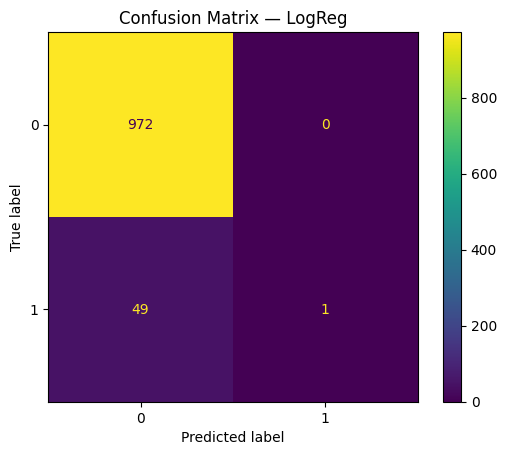

<Figure size 640x480 with 0 Axes>

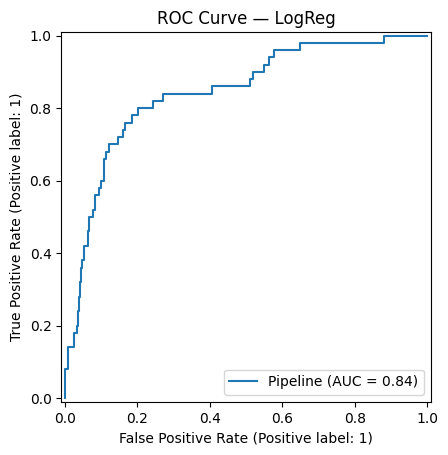

<Figure size 640x480 with 0 Axes>

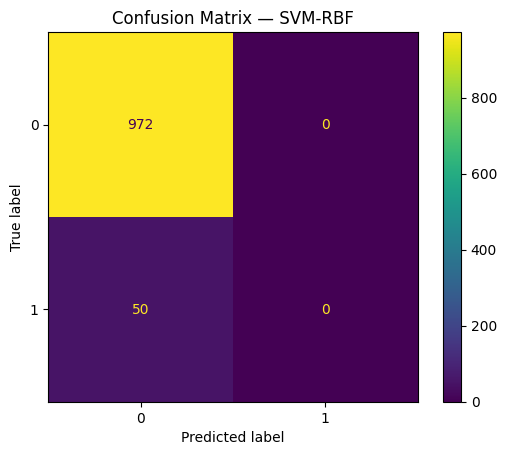

<Figure size 640x480 with 0 Axes>

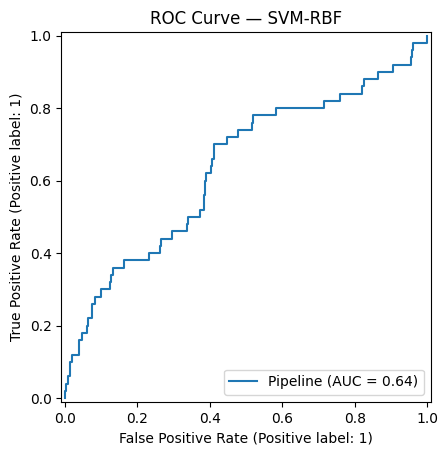

<Figure size 640x480 with 0 Axes>

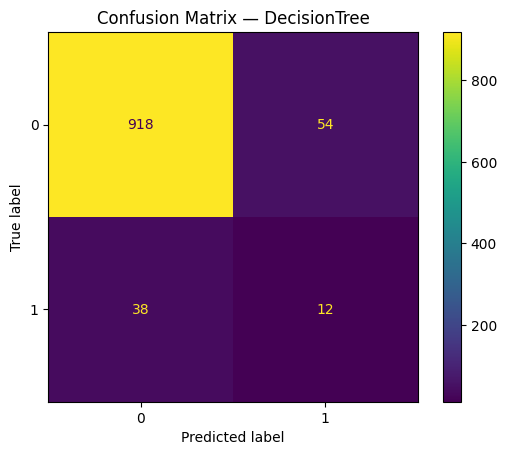

<Figure size 640x480 with 0 Axes>

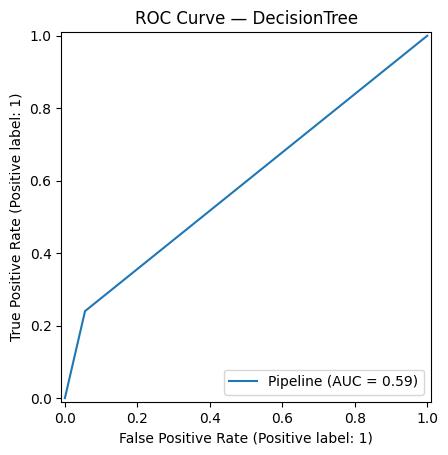

<Figure size 640x480 with 0 Axes>

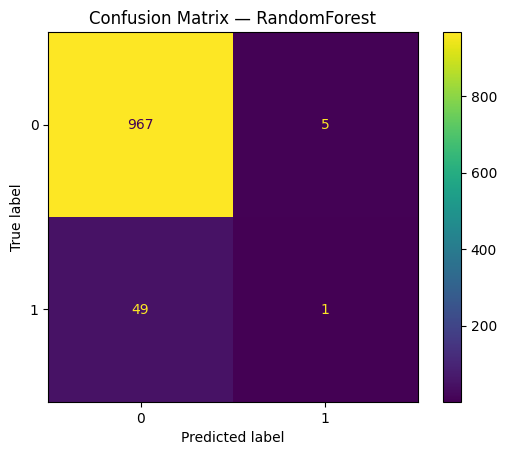

<Figure size 640x480 with 0 Axes>

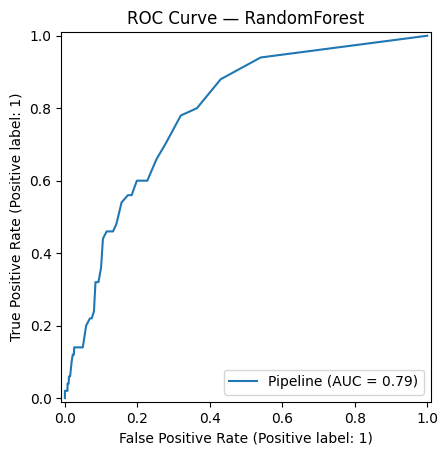

<Figure size 640x480 with 0 Axes>

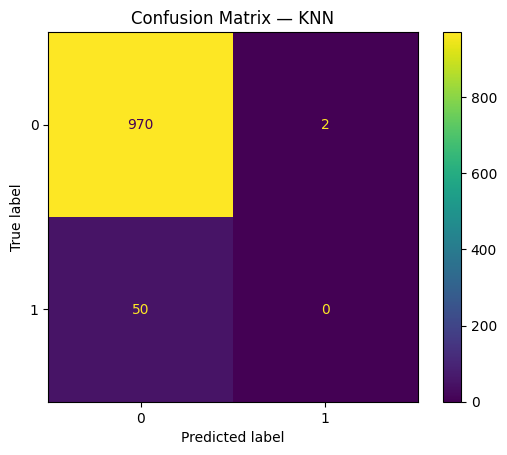

<Figure size 640x480 with 0 Axes>

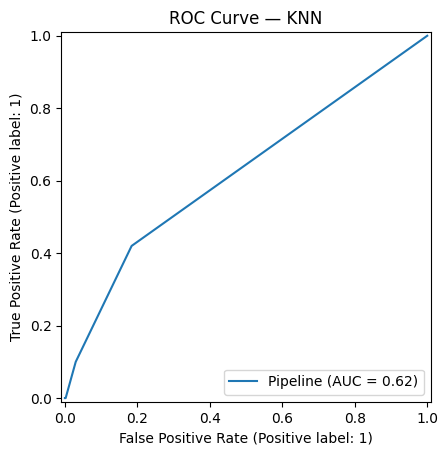

In [15]:
#ROC & Confusion matrix


for name, pipe in pipes.items():
    plt.figure()
    ConfusionMatrixDisplay.from_estimator(pipe, X_test,y_test)
    plt.title(f"Confusion Matrix — {name}")
    plt.show()



    if hasattr(pipe.named_steps["classifier"], "predict_proba"):
      plt.figure()
      RocCurveDisplay.from_estimator(pipe, X_test, y_test)
      plt.title(f"ROC Curve — {name}")
      plt.show()


Besy(pre-tuning): LogReg
Best params: {'clf__C': 0.1, 'clf__max_iter': 100, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best cv AUC: 0.8387


,Label,Accuracy,Precision,Recall,F1,ROC AUC
0,pre,0.952,1.0,0.02,0.039,0.842
1,LogReg (tuned),0.952,1.0,0.02,0.039,0.842


<Figure size 640x480 with 0 Axes>

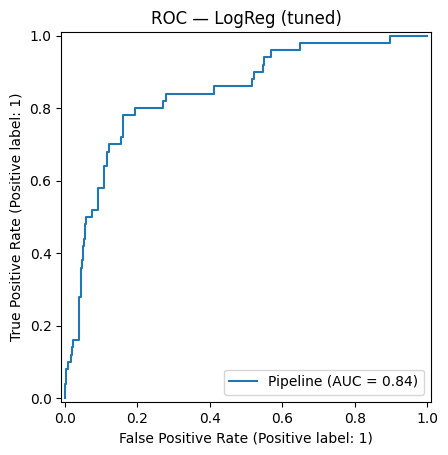

<Figure size 640x480 with 0 Axes>

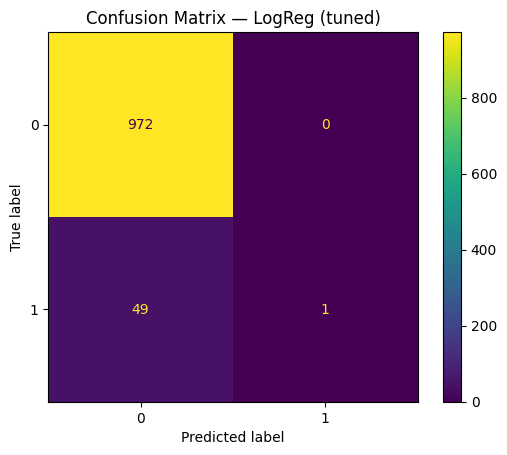

In [16]:
# Gridsearchcv/ comparing before and after





from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
if df_metrics["ROC AUC"].isna().all():
   best_name=df_metrics.sort_values(by=["Recall","F1","Accuracy"], ascending=False).iloc[0]["Model"]

else:
  best_name=df_metrics.iloc[0]["Model"]

print("Besy(pre-tuning):", best_name)

#training model
base_best=pipes[best_name]


def evaluation_metrics(model,label, clf_step_name):
    y_prediction=model.predict(X_test)
    if hasattr(model.named_steps[clf_step_name], "predict_proba"):
        y_score=model.predict_proba(X_test)[:,1]
    elif hasattr(model.named_steps[clf_step_name], "decision_function"):
            y_score=model.decision_function(X_test)
    else:
              y_score=None

    row={
        "Label":label,
        "Accuracy":accuracy_score(y_test,y_prediction),
        "Precision":precision_score(y_test,y_prediction,zero_division=0),
        "Recall":recall_score(y_test,y_prediction,zero_division=0),
        "F1":f1_score(y_test,y_prediction,zero_division=0),
        "ROC AUC":roc_auc_score(y_test,y_score).round(4) if y_score is not None else None,}
    return row

pre_row=evaluation_metrics(base_best,"pre", "classifier")
if best_name == "RandomForest":
  base_estimator=RandomForestClassifier()
  param_grid={
      "clf__n_estimators":[200,400,600],
      "clf__max_depth":[None,10,20],
      "clf__min_samples_split":[2,5],
      "clf__min_samples_split":[1,2]
  }

elif best_name== "LogReg":
 base_estimator=LogisticRegression()
 param_grid={
      "clf__C":[0.1, 1,5,10],
      "clf__penalty":["l2"],
      "clf__solver":["lbfgs", "liblinear"],
      "clf__max_iter":[100,1000]}


elif best_name== "SVM-RBF":
    base_estimator=SVC(probability=True)
    param_grid={
      "clf__c":[0.5, 1,5],
       "clf__gamma":["scale",0.1,0.01]}


elif best_name== "DecisionTree":
    base_estimator=DecisionTreeClassifier()
    param_grid={
      "clf__max_depth":[None, 6 ,12,18],
       "clf__min_samples_split":[2,5,10],
       "clf__min_samples_leaf":[1,2,4]  }
  #KNN
else:

    base_estimator=KNeighborsClassifier()
    param_grid={
      "clf__n_neighbors":[3,5,7,11,15, 21],
       "clf__weights":["uniform","distance"],
       "clf__p":[1,2]}


tune_pipeline= Pipeline([("pre", preprocessing),("clf",base_estimator)])
grid = GridSearchCV(tune_pipeline, param_grid, scoring="roc_auc", cv= 5, n_jobs= -1, verbose=0)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best cv AUC:", round(grid.best_score_,4))




tuned = grid.best_estimator_
post_row = evaluation_metrics(tuned, f"{best_name} (tuned)", "clf")

df_compare = pd.DataFrame([pre_row, post_row]).round(3)
display(df_compare)

#ROC
plt.figure()
RocCurveDisplay.from_estimator(tuned, X_test, y_test)
plt.title(f"ROC — {best_name} (tuned)")
plt.show()

plt.figure()
ConfusionMatrixDisplay.from_estimator(tuned, X_test, y_test)
plt.title(f"Confusion Matrix — {best_name} (tuned)")
plt.show()

In [27]:
from sklearn.utils.multiclass import type_of_target
from sklearn.inspection import permutation_importance


def get_feature_names(column_transformer):
    feature_names = []

    for name, transformer, columns in column_transformer.transformers_:
        if name != 'remainder':
            if hasattr(transformer, 'get_feature_names_out'):
                names = transformer.get_feature_names_out(columns)
            else:
                names = columns
            feature_names.extend(names)
        else:
            if transformer == 'passthrough':
                feature_names.extend(columns)
    return feature_names

feature_names = get_feature_names(preprocessing)



X_test_tr = preprocessing.transform(X_test)

type_y = type_of_target(y_test)

if type_y in ("binary",):
    candidates_scoring = ["roc_auc", "accuracy"]
elif type_y in ("multiclass", "multiclassovr"):
    candidates_scoring = ["roc_auc_ovr", "accuracy"]
else:
    candidates_scoring = ["r2", "neg_mean_squared_error"]

last_scoring_error = None
result = None
scoring_used = None

for sc in candidates_scoring:
    try:
        result = permutation_importance(
            clf, X_test_tr, y_test,n_repeats=10,random_state=42,scoring=sc )



        scoring_used = sc
        break
    except Exception as e:
        last_scoring_error = e
        result = None
        continue


if result is None:
    try:
        result = permutation_importance(
            clf, X_test_tr, y_test,
            n_repeats=10, random_state=42, scoring=None)

        scoring_used = "estimator.score"
    except Exception as e:
        raise RuntimeError(
            f"Could not compute permutation={clf.__class__.__name__}, "
            f"type_y={type_y}, tried={candidates_scoring + ['estimator.score']}. "
            f"Last error: {e if e else last_scoring_error}")


n_feats = len(result.importances_mean)
if len(feature_names) != n_feats:
    print(f" Warning: feature_names length ({len(feature_names)}) does not match importances length ({n_feats}) "
          f"(this usually happens when preprocessing adds or drops columns; truncating names to match the transformed matrix).")

imp = (
    pd.DataFrame({
        "feature": feature_names[:n_feats],
        f"importance_mean({scoring_used})": result.importances_mean,
        "importance_std": result.importances_std})

    .sort_values(by=f"importance_mean({scoring_used})", ascending=False)
    .reset_index(drop=True)
    .round(6))

display(imp.head(20))

,feature,importance_mean(roc_auc),importance_std
0,age,0.102677,0.021641
1,smoking_status_Unknown,0.020213,0.012476
2,Residence_type_Urban,0.006932,0.013396
3,Residence_type_Rural,0.006932,0.013396
4,ever_married_No,0.006151,0.011238
5,ever_married_Yes,0.006151,0.011238
6,gender_Male,0.005748,0.010339
7,gender_Female,0.005748,0.010339
8,avg_glucose_level,0.005715,0.021178
9,heart_disease,0.005521,0.009794
